# Simple Exploration of Optimisation
## Maximum Likelihood Estimator

So far throughout these tutorials we've been using the analytical solution to estimate most of the models, OLS esitmation: 

$$ \hat\beta  = (XX')^{-1}XY $$

This is obviously fine and can be an efficient way to estimate $\beta$ (computationally that is). 

However, OLS is just one unique solution to another way of estimating parameters - **Maximum Liklihood Estimation (MLE)**. 

MLE is basically an optimisation problem that chooses parameters, $\beta$, that are the maximum a models likelihood function. Likelihood functions describe the probability that observed data is generated conditional on other data and some parameters i.e. $ \Pr(y|x,\beta)$.

The parameters are choosen based on the solution to the likelihood function that will maximize the porbability of the model producing data that is the same as the observed data points. 

Whilst not the only way to fit parameters of models, it is a highly popular option manily because of it's abilty to not require distrbutional assumptions for model errors. 

Really handily for our purposes we can actually reframe all our previous OLS estimates into MLE. 

So let's explore what's going on under the hood!

In [1]:
#load in ncessary packages for this notebook
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import pandas as pd
import gc

# simple data example for building models - 
# https://rdrr.io/cran/wooldridge/man/mroz.html
df = pd.read_csv("https://raw.githubusercontent.com/Michael-Morgan-Giles/regression_analysis/refs/heads/main/data/mroz9.csv")
df.head()

# set outcome and covariates
y = "inlf"       # =1 if in lab frce, 1975
X = ['nwifeinc', # (faminc - wage*hours)/1000
     'educ',     # years of schooling
     'exper',    # actual labor mkt exper
     'expersq',  # actual labor mkt exper squared
     'age',      # woman's age in yrs
     'kidslt6',  # number of kids < 6 years
     'lnwage']   # log(wage)

gc.collect()

pd.options.display.float_format = '{:.2f}'.format # just a way to make numbers print nicer 

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   inlf      753 non-null    int64  
 1   kidslt6   753 non-null    int64  
 2   kidsge6   753 non-null    int64  
 3   age       753 non-null    int64  
 4   educ      753 non-null    int64  
 5   unem      753 non-null    float64
 6   exper     753 non-null    int64  
 7   nwifeinc  753 non-null    float64
 8   lnwage    428 non-null    float64
 9   expersq   753 non-null    int64  
dtypes: float64(3), int64(7)
memory usage: 59.0 KB


In [3]:
df['ln_wage_bool'] = df['lnwage'].isna()

df.groupby('inlf')['ln_wage_bool'].sum()

inlf
0    325
1      0
Name: ln_wage_bool, dtype: int64

Note that all of the null wage figures are for those who are not in the labour force. Therefore, I am just going to assume those people have no wage and update those nulls to zero.

In [4]:
df['lnwage'].fillna(0, inplace = True)

### Linear Regression as MLE

As mentioned, we can use MLE to choose a vector $ \beta$ that maximises the observed data matching the output of the model. OLS is a unique solution to this MLE estimator. 

So we have our typical linear model $Y = \beta X + \varepsilon$, and we want to maximise the probabiliy that $\beta$ produces $ Y $ given $X$, i.e.

$$ \Pr(y | X, \beta) $$ 

Now this can become quite a difficult function to optimise (finding the derivatives analytically is not trivial), so we tend to optimise the log of this function i.e.

$$ \ln  \Pr(y | X, \beta) $$

This makes the calculus and linear algebra much easier. So now the MLE estimator is basically just:

$$ \beta_{MLE} \rightarrow \max_{\beta} \ln  \Pr(y | X, \beta) $$ 

Now, even more handily for us, any maximization problem can be turned into a minimisation problem by maximising the inverse of the problem: 

$$ \beta_{MLE} \rightarrow \max_{\beta} \ln  \Pr(y | X, \beta) = \min_{\beta} - \ln  \Pr(y | X, \beta) $$

I won't get too much into the direct derivation of the log-likelihood funciton for a linear model (for more check this article out: ). Rather for our purposes, we can use the following function to esitmate $\beta$:

$$ nll(\beta, \sigma) = \frac{n}{2}\ln(2\pi) + \frac{n}{2}\ln(\sigma^2) + \frac{1}{2\sigma^2}\sum_{i=1}^n (Y - X\beta)^2 $$   


We can use the minisation functions in `scipy` to fit the parameters.Let's code this up and see if there are any differences to either approach. Firstly, lets estimate the model using OLS from `statsmodels`:

In [5]:
print(sm.OLS(df[y],
             sm.add_constant(df[X])).fit().summary())

                            OLS Regression Results                            
Dep. Variable:                   inlf   R-squared:                       0.584
Model:                            OLS   Adj. R-squared:                  0.580
Method:                 Least Squares   F-statistic:                     149.4
Date:                Wed, 01 Jul 2026   Prob (F-statistic):          2.66e-137
Time:                        16:57:37   Log-Likelihood:                -209.15
No. Observations:                 753   AIC:                             434.3
Df Residuals:                     745   BIC:                             471.3
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7209      0.105      6.886      0.0

Okay great, we now have a baseline of $\beta$ to compare to our minimisation outputs below.

Let's compare this to minimising the log-likelihood function and see if we get the same vector of parameters!

In [6]:
# define neg-log-likelihood func
def gausian_ll(params, x, y, n):
    # extract params
    b = params[:-1] 
    sd = params[-1]
    
    # resids
    r = y - x@b
    
    # resids^2
    r2 = np.dot(r.T, r)
    
    return (n / 2) * np.log(2 * np.pi * sd**2) + (r2 / (2 * sd**2))

Now before we get to the minimisation problem itself, we need to set some things up.

Firstly, lets add a vector of ones to the `X` matrix so we calculate the intercept. Similarly, we need to determine both the number of parameters we want to esitmate for $\beta$, but also we need to set up some initial guesses for them. 

This tells the optimisation problem where to start the minimisation algorithm from. Note that for our last element of $\beta$ we are also including the estimate for $\sigma$ as the last element. We will start the guess at 1 because a standard deviation of zero is extremely unlikely. 

In [7]:
# set up parameters and initial guesses
X_matrix = sm.add_constant(df[X]) # adding constant to esitmate \beta_o coefficient
n_params = X_matrix.shape[1] # extracting number of coefficients to be estimated
beta_0 = np.zeros(n_params + 1) # creating a vector of zeros as initial guesses for coefficients
beta_0[-1] = 1.0 # updating last element in vector to guess \sigma to be 1 i.e. standard deviation to be one

The last little thing we need to set up for this linear model is to ensure that $\sigma$ cannot be negative. This involves using the `bounds` arguements in the `minimize()` function. 

This sets the constraints on where the minimisation alogrithm will search. We will ensure that $\sigma > 0$

In [8]:
# creating bounds to ensure sigma can't be negative 
constraints = tuple((None, None) for _ in range(n_params)) + ((1e-20, None),)

This might look a little scary if you're new to coding, but it is just a for loop. The code is creating a list (tuple) of constraints that ensures the last parameter can't be negative (it's bounded by a minimum of 0.00000000000000000001). 

If the for loop looks confusing, maybe the code below might be easier understand:

In [9]:
tuple([(None, None)] * n_params + [(1e-20, None)])

((None, None),
 (None, None),
 (None, None),
 (None, None),
 (None, None),
 (None, None),
 (None, None),
 (None, None),
 (1e-20, None))

Now that we have the data, we know the parameters we want to esitmate, the constriants on those parameters, lets minimize the negative Log-likelihood function!

In [10]:
output = minimize(fun=gausian_ll, 
                  x0=beta_0, 
                  args=(X_matrix, 
                        df[y], 
                        len(df)), 
                  method='L-BFGS-B', 
                  bounds=constraints)

print(output)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 209.15244168470238
        x: [ 7.208e-01 -2.607e-03 -4.093e-03  1.519e-02 -2.367e-04
            -9.671e-03 -1.359e-01  4.061e-01  3.194e-01]
      nit: 227
      jac: [-4.347e-02 -3.501e-01 -4.926e-01 -4.780e-01 -4.425e-01
            -1.156e+00 -6.139e-04 -1.120e-01 -1.813e-01]
     nfev: 2740
     njev: 274
 hess_inv: <9x9 LbfgsInvHessProduct with dtype=float64>


You can see in the print out above some interesting information about the optimisation problem inclusing the function value `fun`, the jacobian `jac` and inverse hessian matrix `hess_inv` all evaluated at the functions optimal values. 

But perhaps of the most interest is the parameter outputs `x`:

In [11]:
print(np.round(output.x,2))

[ 0.72 -0.   -0.    0.02 -0.   -0.01 -0.14  0.41  0.32]


In [12]:
print(sm.OLS(df[y],
             sm.add_constant(df[X])).fit().params)

const       0.72
nwifeinc   -0.00
educ       -0.00
exper       0.02
expersq    -0.00
age        -0.01
kidslt6    -0.14
lnwage      0.41
dtype: float64


Yay they're identical! You will also notice that the log-likelihood in the `OLS()` summary above is the same approximate value as the `fun` output fo the `minimize()` function. Yay!

However, you will note there is an extra parameter in the `minimize()` output, `x`. This is the estimated $\hat \sigma$ parameter estimate. 

Interestingly, it is slightly different than the the `OLS()` output, however it is arbitrarily close to the to each other.

In [13]:
print(np.sqrt(sm.OLS(df[y],
             sm.add_constant(df[X])).fit().scale))

0.321152514576128


The basic reason for this is that the analytical OLS solution tends to be ever so slightly more efficient than the MLE estimate. This means sigma will always be slightly underestimated in the MLE solutions, but that's a bit beyond what we need to get into here. 

For now, we can see how the different esitmates for $\beta$ converge to the same parameters, despite being estimated in two different ways! 

Let's use MLE in a slightly more complex case - a classification problem!

### A (very) brief intro to classification problems
So we've seen we can estimate parameters in a linear regression using MLE. But as mentioned, MLE is also a helpful estimator in other scenarios - perhaps most noteably in classification problems, especially for Logistic Regressions. 

I will not go into depth with logistic regressions (that is for the next chapter), however for our purposes a logistic regression esimtates the probabilty of a binary outcome variable $Y$, given a set of features $X$ and a vector of parameters $\beta$. 

This should sound very familiar. Indeed they're relatively similar to linear regressions except are used for classification instead of regression problems i.e. for discrete outcomes such that $Y \in 0,1$. This will all become more clear in the next sections. 

However, for now, we can use the negative log-likelihood functions for a logistic regression to comapre against the typical stats model estimates. 

The negative likelihood function of a logistic model is: 

$$nll(\beta) =  - \sum -\ln 1 + e^{X\beta} + \sum yX\beta$$

For derivation see:https://www.statlect.com/fundamentals-of-statistics/logistic-model-maximum-likelihood. 

Okay great, we've for the negative log-liklihood function. Let's code this up! 

But again, lets first use the same data from the problem above, but use `statsmodels` to get a baseline estimate for $\beta$: 

In [14]:
print(sm.GLM(df[y],
             sm.add_constant(df[X]),
             family=sm.families.Binomial()).fit(method = "bfgs").summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   inlf   No. Observations:                  753
Model:                            GLM   Df Residuals:                      745
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          bfgs   Log-Likelihood:                -189.29
Date:                Wed, 01 Jul 2026   Deviance:                       378.57
Time:                        16:57:37   Pearson chi2:                 2.51e+05
No. Iterations:                     0   Pseudo R-squ. (CS):             0.5789
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6054      1.174      0.515      0.6

Cool we have the parameters for $\beta$. So similarly to the linear model, lets first define the negative log-liklihood function: 

In [15]:
def nll_logis_reg(beta, y, x):
    return -(-np.log(1 + np.exp(np.dot(x, beta))) + y*np.dot(x,beta)).sum()

In the same way we can put in zeros for the initial guesses of $\beta$ plus an extra one of the intercept. 

In [16]:
beta_0 = np.zeros(len(X) + 1) 

But note we are not esitmate a $\sigma$ in this problem, and we don't have any constraints set on the coefficients (like in the OLS example). 

So we can just get straight into the optimisation problem!

In [17]:
log_reg_output = minimize(fun = nll_logis_reg, 
                          x0 = beta_0,
                          args=(df[y], 
                                sm.add_constant(df[X])),
                          method='BFGS'
                         )

print(log_reg_output)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 189.28546598967313
        x: [ 6.054e-01 -2.532e-02  8.214e-02  9.807e-02 -1.391e-03
            -7.291e-02 -1.129e+00  4.747e+00]
      nit: 28
      jac: [-2.289e-05 -5.875e-04 -3.281e-04 -1.755e-04 -1.804e-03
            -9.041e-04 -1.144e-05 -5.722e-06]
 hess_inv: [[ 1.410e-01  9.213e-05 ... -1.068e-02 -1.298e-01]
            [ 9.213e-05  2.111e-04 ...  1.089e-03 -4.045e-05]
            ...
            [-1.068e-02  1.089e-03 ...  9.458e-02  1.169e-02]
            [-1.298e-01 -4.045e-05 ...  1.169e-02  1.248e-01]]
     nfev: 410
     njev: 45


/tmp/ipykernel_53761/4268913642.py:2: RuntimeWarning: overflow encountered in exp
  return -(-np.log(1 + np.exp(np.dot(x, beta))) + y*np.dot(x,beta)).sum()
/usr/lib/python3/dist-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
/tmp/ipykernel_53761/4268913642.py:2: RuntimeWarning: overflow encountered in exp
  return -(-np.log(1 + np.exp(np.dot(x, beta))) + y*np.dot(x,beta)).sum()


In [18]:
print(np.round(log_reg_output.x,2))

[ 0.61 -0.03  0.08  0.1  -0.   -0.07 -1.13  4.75]


In [19]:
print(sm.GLM(df[y],
             sm.add_constant(df[X]),
             family=sm.families.Binomial()).fit(method = "bfgs").params)

const       0.61
nwifeinc   -0.03
educ        0.08
exper       0.10
expersq    -0.00
age        -0.07
kidslt6    -1.13
lnwage      4.75
dtype: float64


Again we can see that the coefficients for both approaches are identical, yay! 

Now, his is fun and all, but what's quite exciting is that MLE can be used to estimate all sorts of parameters. For example, it can fit a distribution such as the gamma, beta or log-normal distributions. 

It can fit systems of equations you make. 

It's all quite flexible, and now with a rudimentary understanding of what we are trying to achieve with MLE, you can try apply it in other scenarios!

## Numerical optimisation
Now that we've explore MLE, there are other ways to optimise a models parameters. One very common in machine learning / statistics more generally are numerical methods. 

Very basically, numerical methods use the ability of computers to quickly transform large data structures using algorithims. In fact, we've actually been using this to minimise the log-likelihood functions already (note the `method` arguement we've been setting this whole time). 

However, instead of optimising the log-liklihood function, we can also use numerical methods to directly minimise a "cost" or "loss" function. 

As a simple example let's optimise a linear model by minimise the sum of squared residuals (hopefully that sounds familiar!):

$$ SSR = (y - \beta X)'(y - \beta X) = \|y - \beta X\|_2$$

Using the same dataset above, we can find the coefficients by minimising the above cost / loss function: 

In [20]:
# define loss function
def ssr_loss(b, y, x):
    return np.sum((y - x@b).T @ (y - x@b))

In [21]:
np.round(minimize(fun = ssr_loss, 
         x0 = np.zeros(len(X) + 1), # initial guesses foe coefficients all at zero
         args=(df[y], 
               sm.add_constant(df[X])),
         method='BFGS'
         ).x,3)

array([ 0.721, -0.003, -0.004,  0.015, -0.   , -0.01 , -0.136,  0.406])

As you can see the vector is the same as the one calculated above. This can be quite handy if you don't know what the log-likihood function is because you can generally identify some loss function to minimise such as mean squared error (MSE). 

The really cool thing about numerical optimisation is that you can fit really complicated functions quite easily (especially those that can be difficult to solve analytically).

For example pick any complicated looking function and see if we can optimise it! Say maybe this interesting looking function: 

$$ f(x,y) = (x^2 + y - 11)^2 + (x + y^2 - 7)^2 $$

In [22]:
# define a random function
def func(params):
    x, y = params
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

In [23]:
rand_func_output = minimize(fun = func,
                            x0 = (4,1),
                            method='BFGS')

print(rand_func_output)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 7.219185663380434e-15
        x: [ 3.000e+00  2.000e+00]
      nit: 9
      jac: [-4.733e-07  6.083e-08]
 hess_inv: [[ 1.644e-02 -9.752e-03]
            [-9.752e-03  3.521e-02]]
     nfev: 36
     njev: 12


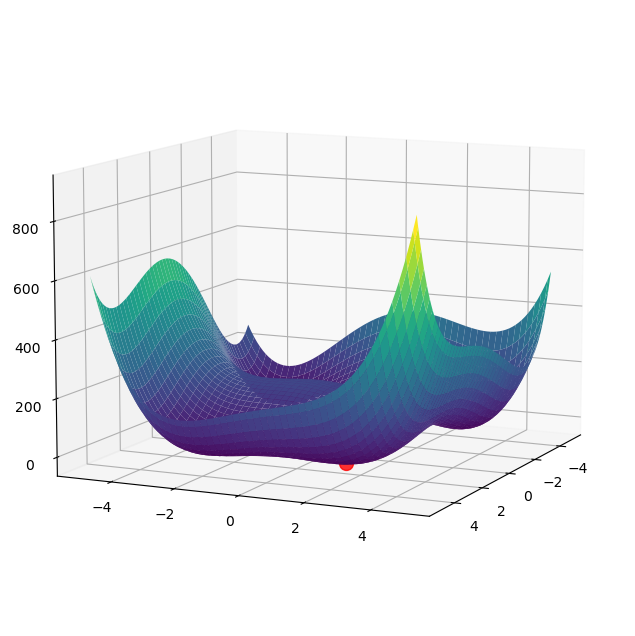

In [24]:
# create lin space for plotting
X, Y = np.meshgrid(np.linspace(-5, 5, 100),
                   np.linspace(-5, 5, 100))
Z = func((X, Y))

# plot surfcae
fig = plt.figure(figsize=(16,8))
ax = plt.axes(projection='3d')
ax.plot_surface(X,Y,Z, 
                cmap='viridis')

# create dot
ax.scatter([rand_func_output.x[0]], 
           [rand_func_output.x[1]], 
           [func(rand_func_output.x)], 
           color='red', 
           s=100, 
           alpha = 0.8,
           label='Minimum point for function')

# show
ax.view_init(elev=10, azim=25) # mess around with these values to change the view
plt.show()

As you can see this actually turns out to look quite complex when you plot the surface of the function. 

This is actually a Himmelblau function. It is often used in mathematical optimisation because it is actually multimodal i.e. has many local minima. 

The one we found is just one of four. Maybe you can play around and see if you can find the other ones (hint, you might need to update the initial guesses).

It is worth noting that despite being able to fit complex functions quite easily, it can come at quite a high computational cost. But at small scales like this it's quite inisgnificant (this is only a problem when working with really big sets of high deimensional data).

Hopefully this brief introduction into optimisation has helped illuminate what is going on under the hood when we "fit", "estimate" or "train" models, and not just seem like arcane code that spits out numbers magically.